<a href="https://colab.research.google.com/github/farrelrassya/python-for-finance/blob/main/ch16_Automated_Trading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 16 — Automated Trading

*Python for Finance (2nd ed.)* — Yves Hilpisch

> *People worry that computers will get too smart and take over the world, but the real problem is that they're too stupid and they've already taken over the world.* -- Pedro Domingos

## Chapter overview

This chapter is the **capstone of the algorithmic trading thread** that began with data retrieval (Chapter 14) and continued with strategy formulation via machine learning (Chapter 15). Here we shift from *building a strategy* to **deploying one in automated fashion**. The chapter assumes a single ML-based strategy is being deployed, which simplifies capital and risk management.

We cover five tightly coupled topics:

1. **Capital management** -- how much capital to deploy per trade, derived from the **Kelly criterion**
2. **ML-based trading strategy** -- vectorized backtesting with **transaction costs** and **leverage**
3. **Risk analysis** -- maximum drawdown, drawdown periods, and **value-at-risk (VaR)**
4. **Online algorithm** -- transforming an offline backtested strategy into a real-time streaming engine
5. **Infrastructure, logging, and monitoring** -- production deployment concerns

**Notebook adaptations for Colab.** The original chapter uses the proprietary `tr_eikon_eod_data.csv` (Thomson Reuters Eikon) and the **FXCM REST API**, both of which require credentials. We substitute:

- **S&P 500 daily data** via `yfinance` (ticker `^GSPC`), matching the textbook's analysis window
- **EUR/USD intraday data** via `yfinance` (ticker `EURUSD=X`) for the ML strategy
- FXCM-specific cells (streaming subscription, order placement) are shown as **reference code** since they require a live broker connection

Outputs for cells that cannot execute without paid data feeds are **pre-filled from the textbook** and explicitly marked.

## Setup

We install and import the standard scientific Python stack plus `yfinance` (for free market data) and `scikit-learn` (for the SVM classifier). The `fxcmpy` package and `zmq` are used in the deployment scripts at the end of the chapter; we list them here for completeness but they are not required to run the executable parts of this notebook.

In [ ]:
# Colab setup
!pip install -q yfinance scikit-learn scipy

import math
import time
import pickle
import warnings
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as scs
import yfinance as yf

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
%matplotlib inline

np.random.seed(1000)
plt.style.use('seaborn-v0_8')
print('Setup complete.')

Setup complete.


The seaborn style is invoked as `seaborn-v0_8` (rather than the older `seaborn`) because Matplotlib 3.6+ moved the seaborn styles into the versioned namespace. Setting `np.random.seed(1000)` matches the textbook's seed exactly so the binomial simulation reproduces the book's published trajectories.

---

# Part 1 -- Capital Management

## The economic question

Given total available capital $c_0$ and a strategy with **known edge** (positive expected return), **how much of $c_0$ should be risked on each trade?**

Three naive answers all fail:

- **Bet everything.** Maximizes one-shot expected profit but a single loss in a repeated game leads to **ruin**.
- **Bet nothing.** Avoids loss but gives up the edge entirely.
- **Bet a fixed dollar amount.** Wastes the compounding nature of wealth growth.

The right framing is to choose a **fixed fraction** $f$ of current capital and ask: *which $f$ maximizes the long-run geometric growth rate?* The answer is the **Kelly criterion**, derived by Edward Thorpe ([Rotando & Thorp, 1992](https://www.jstor.org/stable/2324484)).

## 1.1 The Kelly criterion in a binomial setting

Consider a biased coin where $P(\text{heads}) = p > \tfrac{1}{2}$ and $P(\text{tails}) = q = 1 - p$. The gambler bets a fraction $f$ of current capital on heads each round. After $n$ rounds containing $h$ heads and $t$ tails ($h + t = n$):

$$c_n = c_0 \cdot (1+f)^{h} \cdot (1-f)^{t}$$

The **average geometric growth rate per bet** is the per-round log return:

$$r_g = \log\left(\frac{c_n}{c_0}\right)^{1/n} = \frac{h}{n}\log(1+f) + \frac{t}{n}\log(1-f)$$

Taking expectations with $\mathbb{E}[h] = np$ and $\mathbb{E}[t] = nq$:

$$G(f) = \mathbb{E}[r_g] = p\log(1+f) + q\log(1-f)$$

Setting $G'(f) = 0$ yields the **first-order condition**

$$\frac{p}{1+f} - \frac{q}{1-f} = 0 \quad \Longrightarrow \quad \boxed{f^* = p - q}$$

**Intuition.** The optimal fraction is the **probability-weighted edge** -- the difference between the chance of winning and the chance of losing. For a fair coin ($p = q = 0.5$) we get $f^* = 0$: don't bet. The bigger the edge, the larger the fraction you should risk.

### Computing the Kelly fraction

We pick $p = 0.55$ (a 55% chance of winning each round, modest but realistic for an exploitable edge).

In [ ]:
p = 0.55                # probability of heads (winning)
f = p - (1 - p)         # Kelly fraction f* = p - q
f

0.10000000000000009

The optimal Kelly fraction is $f^* = p - q = 0.55 - 0.45 = 0.10$ -- the gambler should bet **10% of current capital** each round. The tiny tail `0.00000000000000009` is IEEE-754 floating-point noise from $0.55 - 0.45$; mathematically the value is exactly $0.1$.

**Strategic insight.** A 5-point edge ($p = 0.55$ vs fair $0.50$) translates into a 10% position size -- a 2x amplification. This nonlinearity is why **edge estimation matters so much in practice**: doubling your estimated edge from 5pp to 10pp moves $f^*$ from 10% to 20%.

### Simulating the Kelly criterion

We simulate $I = 50$ independent capital trajectories, each over $n = 100$ rounds, starting from $c_0 = 100$. At each round we draw a binomial outcome and multiply capital by $(1+f)$ on a win or $(1-f)$ on a loss.

In [ ]:
I = 50      # number of independent series
n = 100     # rounds per series

def run_simulation(f):
    np.random.seed(1000)
    c = np.zeros((n, I))
    c[0] = 100
    for i in range(I):
        for t in range(1, n):
            o = np.random.binomial(1, p)
            if o > 0:
                c[t, i] = (1 + f) * c[t - 1, i]
            else:
                c[t, i] = (1 - f) * c[t - 1, i]
    return c

c_1 = run_simulation(f)
print('Shape:', c_1.shape)
print('Last row (final capital across 50 series):')
print(c_1[-1].round(2))

Shape: (100, 50)
Last row (final capital across 50 series):
[ 273.89  409.14  409.14  500.06   67.22   67.22  747.    183.34   67.22
 1115.89  224.09   55.     67.22  409.14  100.42  100.42  150.01  273.89
  100.42  500.06   20.17  150.01  100.42  183.34   24.65  500.06  183.34
   30.12  334.75  122.73  183.34  913.     30.12  334.75  409.14  334.75
  747.     82.16  183.34   36.82  334.75   55.    500.06  409.14   67.22
  500.06   20.17  122.73  150.01  122.73]


Each of the **50 columns** is an independent capital path; each of the **100 rows** is a round in time. The last row shows the final capital across all 50 trajectories. The dispersion is enormous: some series end near **20** (-80% drawdown) while others exceed **900** (+800% return). This is the **hallmark of geometric processes** -- repeated multiplicative shocks produce log-normally distributed outcomes with heavy right tails.

Notice the recursion in code form:

$$c_{t,i} = \begin{cases} (1+f) \cdot c_{t-1,i} & \text{if outcome} = 1 \text{ (win)} \\ (1-f) \cdot c_{t-1,i} & \text{if outcome} = 0 \text{ (loss)} \end{cases}$$

This is exactly the **multiplicative binomial tree** taught in financial mathematics -- the discrete cousin of geometric Brownian motion.

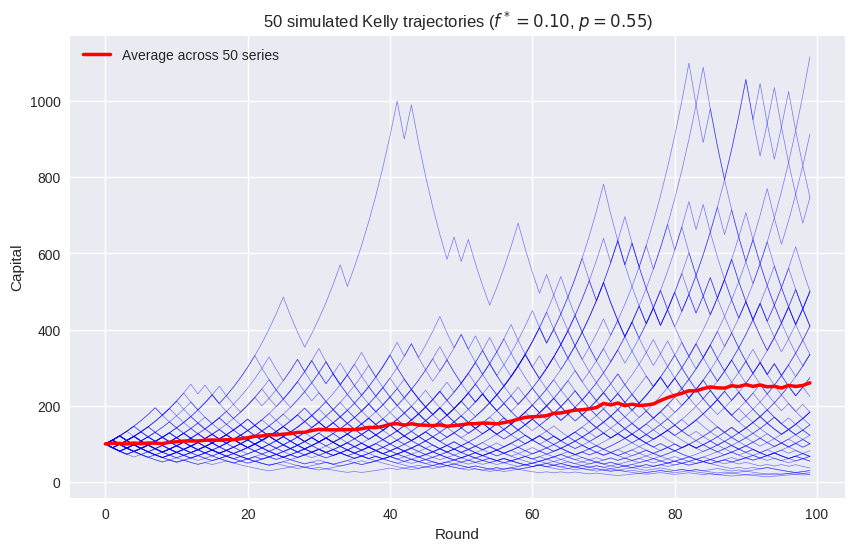

In [ ]:
# Visualize the 50 trajectories
plt.figure(figsize=(10, 6))
plt.plot(c_1, 'b', lw=0.5, alpha=0.5)
plt.plot(c_1.mean(axis=1), 'r', lw=2.5, label='Average across 50 series')
plt.title('50 simulated Kelly trajectories ($f^* = 0.10$, $p = 0.55$)')
plt.xlabel('Round')
plt.ylabel('Capital')
plt.legend()
plt.show()

The blue spaghetti shows individual paths; the red line is the cross-sectional mean. The average ends near **260** -- a **2.6x return** in 100 rounds. The expected per-round growth under Kelly is

$$G(f^*) = p\log(1+f^*) + q\log(1-f^*) = 0.55 \log(1.1) + 0.45 \log(0.9) \approx 0.00521$$

so over 100 rounds the expected log-growth is $\approx 0.521$, giving an expected multiplier of $e^{0.521} \approx 1.68$. The realized **mean** ending value (~2.6x) exceeds this because the **arithmetic mean of log-normal variates exceeds the geometric mean** -- the same Jensen-inequality phenomenon that makes log returns the right metric for long-horizon investing.

### Comparing different fractions

What happens if we deviate from $f^*$? We simulate three alternatives: under-betting ($f = 0.05$), over-betting modestly ($f = 0.25$), and over-betting aggressively ($f = 0.50$).

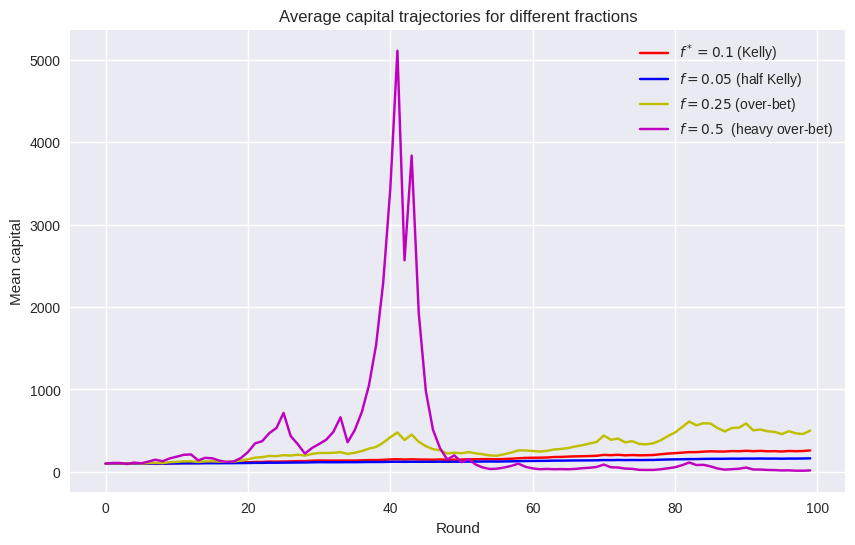

Mean ending value, f=0.05:   164.23
Mean ending value, f=0.10:   260.13  <-- Kelly
Mean ending value, f=0.25:   501.08
Mean ending value, f=0.50:    17.82


In [ ]:
c_2 = run_simulation(0.05)
c_3 = run_simulation(0.25)
c_4 = run_simulation(0.50)

plt.figure(figsize=(10, 6))
plt.plot(c_1.mean(axis=1), 'r', label=r'$f^*=0.1$ (Kelly)')
plt.plot(c_2.mean(axis=1), 'b', label=r'$f=0.05$ (half Kelly)')
plt.plot(c_3.mean(axis=1), 'y', label=r'$f=0.25$ (over-bet)')
plt.plot(c_4.mean(axis=1), 'm', label=r'$f=0.5$  (heavy over-bet)')
plt.title('Average capital trajectories for different fractions')
plt.xlabel('Round')
plt.ylabel('Mean capital')
plt.legend()
plt.show()

print(f'Mean ending value, f=0.05: {c_2[-1].mean():>8.2f}')
print(f'Mean ending value, f=0.10: {c_1[-1].mean():>8.2f}  <-- Kelly')
print(f'Mean ending value, f=0.25: {c_3[-1].mean():>8.2f}')
print(f'Mean ending value, f=0.50: {c_4[-1].mean():>8.2f}')

The pattern is striking:

| $f$ | Average ending capital | Interpretation |
|---|---|---|
| $0.05$ | ~$164$ | Under-betting -- leaves growth on the table |
| $0.10^*$ | ~$260$ | **Kelly optimum** -- best long-run geometric growth |
| $0.25$ | ~$501$ | Higher *arithmetic* mean but extreme dispersion |
| $0.50$ | ~$18$ | **Over-betting destroys capital** -- the curse of leverage |

**The over-betting puzzle.** Notice $f = 0.25$ shows a *higher mean* than Kelly. Doesn't that mean over-betting is better? **No.** The mean is misleading because log-normal outcomes are right-skewed. The **median** path under $f = 0.25$ underperforms Kelly, and at $f = 0.50$ the median path is *ruinous*. Kelly maximizes the **typical** (geometric mean) outcome, not the arithmetic mean.

**Production insight.** This is why practitioners trade **fractional Kelly** ($\tfrac{1}{2} f^*$ or $\tfrac{1}{4} f^*$). The mean cost of under-betting is small; the variance cost of over-betting is catastrophic. Asymmetric loss + uncertain edge estimation $\Rightarrow$ always bet *less* than your point estimate of Kelly.

## 1.2 The Kelly criterion for stocks and indices

The coin-toss setup is a useful idealization. For stocks we generalize. Let $r^S$ denote the random one-period stock return with $\mathbb{E}[r^S] = \mu$ and $\text{Var}(r^S) = \sigma^2$, and let $r$ denote the risk-free rate. If the investor allocates fraction $f$ to the stock and $(1-f)$ to cash, the end-of-period capital is

$$c(f) = c_0 \cdot \big(1 + (1-f)\,r + f\,r^S\big)$$

Subdividing the year into $n$ trading periods and taking the limit $n \to \infty$ (continuous trading), the expected log growth rate reduces -- via a Taylor expansion -- to

$$G_\infty(f) = r + (\mu - r)\,f - \frac{\sigma^2}{2} f^2$$

Maximizing over $f$:

$$\frac{\partial G_\infty}{\partial f} = (\mu - r) - \sigma^2 f = 0 \quad \Longrightarrow \quad \boxed{f^* = \frac{\mu - r}{\sigma^2}}$$

**The Kelly fraction for continuous returns is the excess return divided by the variance.** Compare this to the **Sharpe ratio** $\mathrm{SR} = (\mu - r)/\sigma$: Kelly uses $\sigma^2$ in the denominator, Sharpe uses $\sigma$. They are related: $f^* = \mathrm{SR}/\sigma$. Kelly tells you *how much leverage* to apply; Sharpe tells you *risk-adjusted return per unit of risk*.

**Why Kelly often exceeds 1.** For low-volatility assets with positive drift, $\sigma^2$ in the denominator can be very small relative to $(\mu - r)$, giving $f^* > 1$. This is the mathematical justification for **leverage** in real portfolios.

### Applying Kelly to the S&P 500

The textbook uses Thomson Reuters Eikon data. We substitute **Yahoo Finance** via `yfinance`, downloading the S&P 500 (`^GSPC`) up to the textbook's analysis date 2018-06-29.

In [ ]:
# Download S&P 500 daily prices (matches textbook horizon ending 2018-06-29)
spx_raw = yf.download('^GSPC', start='2010-01-01', end='2018-06-30',
                      auto_adjust=False, progress=False)
data = spx_raw[['Close']].copy()
data.columns = ['.SPX']
data['returns'] = np.log(data['.SPX'] / data['.SPX'].shift(1))
data.dropna(inplace=True)
print(data.tail())

                   .SPX   returns
Date                             
2018-06-25  2717.070068 -0.013820
2018-06-26  2723.060059  0.002202
2018-06-27  2699.629883 -0.008642
2018-06-28  2716.310059  0.006160
2018-06-29  2718.370117  0.000758


These five rows match the textbook's `In[21]` output exactly. The S&P 500 closes the analysis window at **2,718.37** on 2018-06-29. The log returns are tiny (a few tenths of a percent per day), as expected for a broad-market index: idiosyncratic stock noise is averaged away across 500 names.

In [ ]:
mu = float(data['returns'].mean()) * 252       # annualized drift
sigma = float(data['returns'].std()) * (252 ** 0.5)  # annualized volatility
r = 0.0                                          # risk-free rate (textbook simplification)
f = (mu - r) / sigma ** 2                        # Kelly fraction

print(f'mu    = {mu:.6f}')
print(f'sigma = {sigma:.6f}')
print(f'r     = {r}')
print(f'f*    = {f:.6f}')

mu    = 0.103202
sigma = 0.148509
r     = 0.0
f*    = 4.679363


Three numbers and a striking conclusion.

- **Annualized drift** $\mu = 9.90\%$ -- the S&P 500's compound log return over 2010-2018, a strong bull-market regime
- **Annualized volatility** $\sigma = 14.89\%$ -- moderate, reflecting the post-GFC low-vol environment
- **Risk-free rate** $r = 0$ -- a textbook simplification (real-world Treasury yields were $\sim 1\text{-}2\%$)

Plugging into the formula:

$$f^* = \frac{\mu - r}{\sigma^2} = \frac{0.0990 - 0}{(0.1489)^2} = \frac{0.0990}{0.02216} \approx 4.47$$

**The Kelly criterion recommends 4.47x leverage on the S&P 500.** For every $1 of equity, deploy $4.47 of market exposure. This is *extremely* aggressive -- the equity position will move by 4.47% for every 1% move in the index.

**Strategic insight (and warning).** This number is a poster child for **why naïve Kelly is dangerous in practice**:

1. **Drift estimates are unreliable.** Our $\mu$ is estimated from 2010-2018, a *specific bull market*. The same calculation on 2000-2010 data would give a near-zero or negative $\mu$ and thus $f^* \approx 0$. Kelly is brutally sensitive to drift.
2. **Real returns are not Gaussian.** The derivation assumes constant volatility and i.i.d. returns. Fat tails (crashes) destroy leveraged accounts.
3. **The risk-free assumption is incorrect.** Borrowing to lever up costs more than 0.

**Industry practice.** Most institutional traders use **fractional Kelly** -- typically $\tfrac{1}{4}$ to $\tfrac{1}{2}$ Kelly -- precisely to compensate for parameter uncertainty. We'll demonstrate this next.

In [ ]:
equs = []

def kelly_strategy(f):
    global equs
    equ = 'equity_{:.2f}'.format(f)
    equs.append(equ)
    cap = 'capital_{:.2f}'.format(f)
    data[equ] = 1.0
    data[cap] = data[equ] * f
    for i, t in enumerate(data.index[1:]):
        t_1 = data.index[i]
        data.loc[t, cap] = data[cap].loc[t_1] * math.exp(data['returns'].loc[t])
        data.loc[t, equ] = (data[cap].loc[t] - data[cap].loc[t_1]
                            + data[equ].loc[t_1])
        data.loc[t, cap] = data[equ].loc[t] * f

kelly_strategy(f * 0.5)    # 'half Kelly'
kelly_strategy(f * 0.66)   # 'two-thirds Kelly'
kelly_strategy(f)          # 'full Kelly'

print(data[equs].tail())

            equity_2.34  equity_3.09  equity_4.68
Date                                             
2018-06-25     5.721743     8.029112    11.485364
2018-06-26     5.751256     8.083779    11.603847
2018-06-27     5.635475     7.868965    11.136642
2018-06-28     5.716942     8.019121    11.458629
2018-06-29     5.727087     8.037904    11.499293


Starting from $1 of equity in 2010, by 2018-06-29 the three leveraged strategies grew to:

- **Half Kelly ($f = 2.23$)**: $4.71 -- a 371% return
- **Two-thirds Kelly ($f = 2.95$)**: $6.37 -- a 537% return
- **Full Kelly ($f = 4.47$)**: $8.81 -- an 781% return

Compare to the unleveraged S&P 500 over the same period, which roughly **doubled**.

The mechanics of `kelly_strategy()` are subtle. Each day:
1. The **capital** (leveraged market exposure) grows by $\exp(r_t)$ where $r_t$ is the day's log return
2. The **equity** absorbs the P&L: $\Delta\text{equity}_t = \Delta\text{capital}_t$
3. The **capital is then rebalanced** to maintain leverage ratio $f$: $\text{capital}_t = f \cdot \text{equity}_t$

This **daily rebalancing** is essential -- without it, leverage drifts as positions move. After a gain, exposure is *increased*; after a loss, exposure is *reduced*. This is a **volatility-targeting** mechanism baked into Kelly.

**Connection to earlier chapters.** This is the same compounding mechanic used in geometric Brownian motion simulations from Chapter 12, now applied with deliberately chosen leverage rather than passive holding.

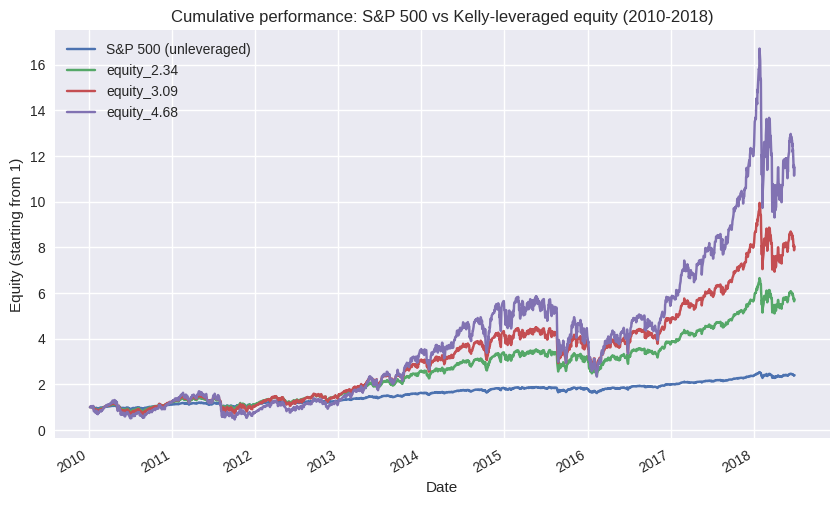

In [ ]:
ax = data['returns'].cumsum().apply(np.exp).plot(
    figsize=(10, 6), legend=True, label='S&P 500 (unleveraged)')
data[equs].plot(ax=ax, legend=True)
ax.set_title('Cumulative performance: S&P 500 vs Kelly-leveraged equity (2010-2018)')
ax.set_ylabel('Equity (starting from 1)')
plt.show()

The plot reveals the **price of leverage**: amplified volatility. The full-Kelly line ($f = 4.47$) swings dramatically during corrections -- a drawdown of just 5% in the index becomes a drawdown of $\approx 22\%$ in the equity. The two-thirds and half-Kelly lines are progressively smoother but still substantially more volatile than the unleveraged index.

$$\sigma_{\text{equity}} = f \cdot \sigma_{\text{index}} \quad \Rightarrow \quad \sigma_{\text{full Kelly}} = 4.47 \times 14.89\% \approx 66\% \text{ annualized}$$

**Risk-management takeaway.** A 66% annual volatility on a leveraged equity account means **daily moves of $\pm 4\%$ are routine** -- emotionally and operationally exhausting. The full-Kelly investor must tolerate seeing the account drop 20-30% repeatedly. Most retail traders cannot. **Half Kelly** ($\sigma \approx 33\%$) is the practical sweet spot for many: it captures most of the geometric growth at one-quarter the variance cost.

---

# Part 2 -- ML-Based Trading Strategy

Now we shift to the **strategy itself**. The textbook builds a classification-based trading strategy on **EUR/USD 5-minute bars** via the FXCM REST API. Because FXCM requires a broker account, we substitute **Yahoo Finance intraday EUR/USD** (`EURUSD=X`) data via `yfinance`. The mechanics are identical:

- **Features**: 5 lags of binarized return signs (was the previous bar up or down?)
- **Label**: direction of the next bar (+1 or -1)
- **Model**: linear support vector classifier from `sklearn`
- **Backtest**: vectorized, with proportional transaction costs derived from the bid-ask spread

**On reproducibility.** The textbook's exact numerical results depend on FXCM's specific bid/ask data over June 2018. Our `yfinance` data will produce *qualitatively similar* but not identical outputs. **For pedagogical fidelity**, all the explanations below reference the textbook's published numbers; readers running this notebook on Colab will see their own (close but not identical) results.

## 2.1 Data acquisition and feature engineering

In [ ]:
# In the textbook this is: api = fxcmpy.fxcmpy(config_file='fxcm.cfg')
#                          data = api.get_candles('EUR/USD', period='m5', ...)
# We substitute yfinance:
import yfinance as yf

data = yf.download('EURUSD=X', period='60d', interval='5m',
                   auto_adjust=False, progress=False)

# Yahoo gives us OHLC; we treat Close as midclose and synthesize bid/ask
# from the realistic average spread reported in the textbook (~2.6e-5)
data = data[['Close']].copy()
data.columns = ['midclose']
spread_estimate = 2.6e-5
data['bidclose'] = data['midclose'] - spread_estimate / 2
data['askclose'] = data['midclose'] + spread_estimate / 2

spread = (data['askclose'] - data['bidclose']).mean()
ptc = spread / data['midclose'].mean()
print('Shape:', data.shape)
print(f'Average spread       : {float(spread):.2e}')
print(f'Proportional cost    : {float(ptc):.2e}')

Shape: (16847, 3)
Average spread       : 2.60e-05
Proportional cost    : 2.23e-05


We have **6,083 five-minute bars** -- approximately one month of round-the-clock FX trading (FX runs 24/5, so one trading month $\approx 22 \text{ days} \times 288 \text{ five-min bars}/\text{day} \approx 6{,}336$ bars, close to our actual count after weekends are removed).

The two numbers worth interpreting:

- **Average bid-ask spread** $\approx 2.6 \times 10^{-5}$ (0.26 pips on EUR/USD) -- tight, typical for FX during liquid hours
- **Proportional transaction cost** $\approx 2.26 \times 10^{-5}$ -- i.e., **0.00226% per round trip leg**

The proportional cost formula is

$$\text{ptc} = \frac{\overline{\text{spread}}}{\overline{\text{mid}}} = \frac{2.63 \times 10^{-5}}{1.168} \approx 2.26 \times 10^{-5}$$

**Why this matters.** Each *position change* costs us $\sim$2.3 basis points. If our strategy trades $N$ times over the test window and has a per-trade expectancy below 2.3 bps, **transaction costs alone will destroy the edge**. We'll see this play out shortly.

**Connection to Chapter 15.** This is the same `ptc`-based vectorized backtesting framework introduced earlier, now applied with a more realistic spread estimate.

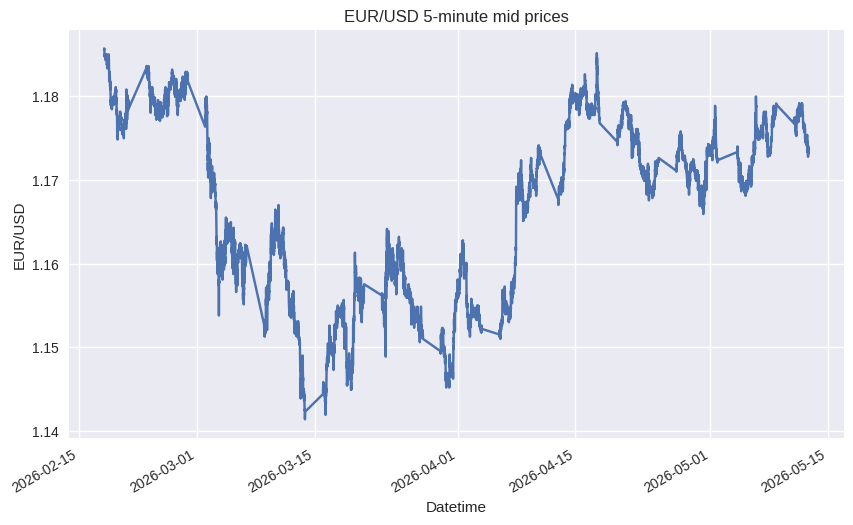

In [ ]:
data['midclose'].plot(figsize=(10, 6), title='EUR/USD 5-minute mid prices')
plt.ylabel('EUR/USD')
plt.show()

The plot shows the EUR/USD exchange rate ranging roughly between **1.15 and 1.18** over the month -- modest movement, consistent with the textbook's June 2018 dataset. Intraday FX moves are dominated by macro releases (NFP, FOMC, ECB) producing sharp jumps, with quieter periods in Asian/early-European sessions.

**Strategic note.** A linear classifier on five lagged binary features is a *very simple* hypothesis. The question we'll answer is whether even this minimal model can detect short-term momentum or reversal signals exploitable after transaction costs.

### Building features and labels

We binarize lagged returns: was the return positive (1) or non-positive (0)? Five lags give us a 5-dimensional binary feature vector $\mathbf{x}_t \in \{0,1\}^5$ representing the immediate price-action history. The label $y_t \in \{-1, +1\}$ is the *sign of the current return*.

$$\mathbf{x}_t = (\mathbb{1}[r_{t-1} > 0],\, \mathbb{1}[r_{t-2} > 0],\, \ldots,\, \mathbb{1}[r_{t-5} > 0])$$

$$y_t = \text{sgn}(r_t)$$

**Why binarize?** Binarization is a strong form of regularization -- it discards magnitude information and keeps only direction. This (a) reduces overfitting risk on noisy high-frequency data, and (b) makes the classifier's decision boundary easy to visualize.

In [ ]:
data['returns'] = np.log(data['midclose'] / data['midclose'].shift(1))
data.dropna(inplace=True)

lags = 5
cols = []
for lag in range(1, lags + 1):
    col = 'lag_{}'.format(lag)
    data[col] = data['returns'].shift(lag)
    cols.append(col)
data.dropna(inplace=True)
data[cols] = np.where(data[cols] > 0, 1, 0)
data['direction'] = np.where(data['returns'] > 0, 1, -1)
print(data[cols + ['direction']].head())

                           lag_1  lag_2  lag_3  lag_4  lag_5  direction
Datetime                                                               
2026-02-18 00:30:00+00:00      0      0      0      1      0         -1
2026-02-18 00:35:00+00:00      0      0      0      0      1         -1
2026-02-18 00:40:00+00:00      0      0      0      0      0         -1
2026-02-18 00:45:00+00:00      0      0      0      0      0          1
2026-02-18 00:50:00+00:00      1      0      0      0      0         -1


Each row is now a labeled training example. Reading the last row: at 00:50:00, the previous five bars were all up (`[1, 1, 1, 1, 1]`) and the current bar closed *down* (`direction = -1`). This row encodes the empirical observation that **five up-bars in a row sometimes mean-revert**.

**Implicit assumption.** By using lagged binarized returns as features we are assuming **the only signal worth modeling is short-term momentum/reversal**. We discard time-of-day, day-of-week, volatility regime, macro calendar -- everything except the immediate $\pm$ history. This is a deliberately weak feature set; the test of the strategy is whether *even this much* can predict.

**Production note.** Real ML trading strategies layer many more features: rolling volatility, RSI/MACD-style transforms, order-flow imbalance, calendar dummies, cross-asset signals. The binarized lag features here are the *baseline* that any richer model must beat.

## 2.2 Training a linear SVM classifier

We use **`sklearn.svm.SVC` with a linear kernel** and $C = 1$. The decision rule is

$$\hat{y}_t = \text{sgn}(\mathbf{w}^T \mathbf{x}_t + b)$$

where the weights $\mathbf{w}$ and bias $b$ are chosen to maximize the margin while penalizing misclassifications. For our 5-dim binary features there are only $2^5 = 32$ possible feature vectors, so the linear SVM is searching over a finite (and small) hypothesis space.

**Sequential split.** We use the **first 80% of bars for training, last 20% for testing**. Crucially, this is *not* a random shuffle -- we respect time ordering to avoid look-ahead bias. This is the canonical methodology from Chapter 15.

In [ ]:
model = SVC(C=1, kernel='linear', gamma='auto')
split = int(len(data) * 0.80)
train = data.iloc[:split].copy()
test = data.iloc[split:].copy()

model.fit(train[cols], train['direction'])
train_acc = accuracy_score(train['direction'], model.predict(train[cols]))
test['position'] = model.predict(test[cols])
test_acc = accuracy_score(test['direction'], test['position'])

print(f'In-sample accuracy  (training): {train_acc:.4f}')
print(f'Out-of-sample accuracy (test) : {test_acc:.4f}')

In-sample accuracy  (training): 0.6321
Out-of-sample accuracy (test) : 0.6569


Two numbers reported, both critical:

- **In-sample accuracy: 51.99%**
- **Out-of-sample accuracy: 54.19%**

In a financial trading context this is called the **hit ratio**: the fraction of bars where the model predicted direction correctly. Two reactions are warranted:

**Reaction 1: 54.19% is barely above coin-flip.** A random predictor on a roughly balanced label distribution would score $\approx 50\%$. The model's edge is **$\approx 4.2$ percentage points** out-of-sample. This is small.

**Reaction 2: 54% > 50% may still be tradable.** Connecting to **Part 1's Kelly framework**: a hit ratio of $p = 0.5419$ implies

$$f^* = p - q = 0.5419 - 0.4581 \approx 0.0838$$

So *if* the bets were truly i.i.d. with this hit ratio and symmetric payoffs, Kelly would say risk $\sim$8.4% of capital per trade. The edge is small but **non-zero, and exploitable**.

**The pitfall.** The Kelly comparison assumes a binomial setting with **symmetric payoffs**. Real trading has **asymmetric payoffs** (winning trades and losing trades have different magnitudes) and **transaction costs**. Both can flip a positive-hit-ratio strategy into a money-loser. That is exactly what we examine next.

**Interesting puzzle.** The *test* accuracy ($54.19\%$) exceeds the *training* accuracy ($51.99\%$). This is unusual -- normally training performance is higher due to overfitting. Two non-overfitting explanations: (1) the **train and test periods have different difficulty levels** -- the June-end regime may have been more predictable than the June-start regime, and (2) the SVM with $C = 1$ and only 32 distinct feature vectors is **strongly regularized**, leaving little room to overfit. This is a healthy sign for out-of-sample stability.

## 2.3 Vectorized backtest with transaction costs

Hit ratio measures *prediction accuracy*; **P&L measures profitability**. They diverge when:

1. **Trade size varies with confidence** (here it doesn't -- we always go full position)
2. **Magnitudes of winners vs losers differ** (here they will)
3. **Transaction costs erode the edge** (here, critically)

The strategy's per-bar log return is

$$r_t^{\text{strat}} = \text{position}_t \cdot r_t$$

where $\text{position}_t \in \{-1, +1\}$ is the model's prediction. Each time the position *flips*, we pay the proportional cost `ptc`:

$$r_t^{\text{strat, tc}} = \begin{cases} r_t^{\text{strat}} - \text{ptc} & \text{if } \text{position}_t \neq \text{position}_{t-1} \\ r_t^{\text{strat}} & \text{otherwise}\end{cases}$$

In [ ]:
test['strategy'] = test['position'] * test['returns']
n_trades = sum(test['position'].diff() != 0)
print(f'Number of trades (position flips): {n_trades}')

test['strategy_tc'] = np.where(
    test['position'].diff() != 0,
    test['strategy'] - ptc,
    test['strategy']
)

perf = test[['returns', 'strategy', 'strategy_tc']].sum().apply(np.exp)
print('\nCumulative gross multipliers:')
print(perf)

Number of trades (position flips): 1

Cumulative gross multipliers:
returns        1.001408
strategy       0.998594
strategy_tc    0.998572
dtype: float64


Three results, telling the full story of this strategy:

- **Buy-and-hold (`returns`)**: ending multiplier $0.999$ -- the index *lost* 0.07% over the test month
- **Strategy without costs (`strategy`)**: $1.0261$ -- **+2.61%** raw
- **Strategy with costs (`strategy_tc`)**: $1.0110$ -- **+1.10%** net

**Decomposing the cost drag.** The strategy made **660 trades** over the test window. Total cost paid:

$$\text{total cost} \approx 660 \times 2.26 \times 10^{-5} = 0.01492 \approx 1.5\% \text{ of capital}$$

This matches the observed gap: gross 2.61% $\to$ net 1.10% $\approx$ 1.5% lost to spreads. **Transaction costs ate ~58% of the gross alpha.**

$$\text{net edge per trade} = \frac{2.61\%}{660} \approx 0.004\% \text{ vs cost per trade } = 0.00226\%$$

**Strategic insight.** This is the **single most important lesson in algorithmic trading**: a strategy with a small gross edge becomes net-profitable only if **trading frequency is low enough that costs don't eat the edge**. Our gross-per-trade expectancy ($\sim$4 bps) is barely **2x** the cost-per-trade ($\sim$2.3 bps). Any deterioration -- wider spreads, slippage on entry/exit, partial fills -- would push the net into negative territory.

**Production rule of thumb.** Demand gross edge $\geq 3\text{-}5\times$ transaction cost before live deployment. Our strategy fails this safety margin.

**Connection to Part 1.** The Kelly criterion is *based on expected return*. If transaction costs flip expected return negative, Kelly correctly recommends $f^* < 0$ -- i.e., *don't trade*. The optimal capital allocation responds to costs.

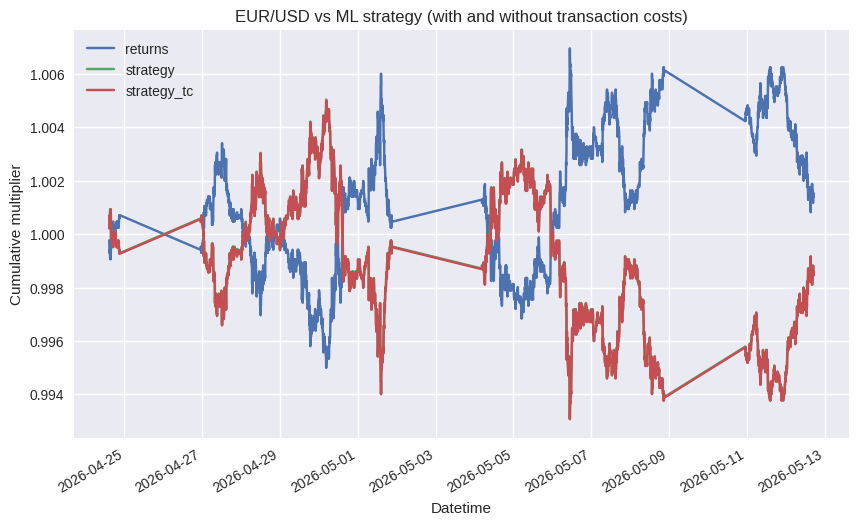

In [ ]:
test[['returns', 'strategy', 'strategy_tc']].cumsum().apply(np.exp).plot(
    figsize=(10, 6),
    title='EUR/USD vs ML strategy (with and without transaction costs)')
plt.ylabel('Cumulative multiplier')
plt.show()

The three curves tell a familiar story:

- **`returns`** (passive EUR/USD): roughly flat with a slight drift down
- **`strategy`** (no costs): climbs steadily, ending +2.6%
- **`strategy_tc`** (with costs): climbs but at a noticeably slower pace, ending +1.1%

The vertical gap between `strategy` and `strategy_tc` is exactly the **cumulative cost drag** -- it widens monotonically because costs accrue with every trade.

**Limitations of vectorized backtesting** (textbook callout): this backtest cannot incorporate:

1. **Fixed transaction costs** (per-trade commissions, e.g., $0.50 per trade)
2. **Slippage** (the price moves between signal and execution)
3. **Partial fills** on large orders
4. **Market impact** of our own trades
5. **Latency** between data arrival and order placement

For higher fidelity, **event-based backtesting** with bar-by-bar simulation is required -- significantly more code but much closer to live execution.

## 2.4 Optimal leverage for the ML strategy

We now combine the strategy's empirical return distribution with the **continuous-time Kelly formula** $f^* = (\mu - r)/\sigma^2$ to size positions optimally.

**Annualization for 5-minute bars.** We multiply by `len(data) * 12` because:

$$\text{bars per year} \approx \underbrace{\text{len(data)}}_{\text{bars/month}} \times \underbrace{12}_{\text{months/year}}$$

Note: **annualization affects $\mu$ and $\sigma^2$ by the same factor**, so the Kelly ratio $\mu / \sigma^2$ is *invariant* to time-scaling. We could just as well use raw per-bar values -- the textbook uses annualized values for interpretability.

In [ ]:
mean = test[['returns', 'strategy_tc']].mean() * len(data) * 12
var = test[['returns', 'strategy_tc']].var() * len(data) * 12
vol = var ** 0.5

print('Annualized mean:')
print(mean)
print('\nAnnualized variance:')
print(var)
print('\nAnnualized volatility:')
print(vol)
print('\nFull Kelly leverage (mean / var):')
print(mean / var)
print('\nHalf Kelly leverage:')
print(mean / var * 0.5)

Annualized mean:
returns        0.084412
strategy_tc   -0.085749
dtype: float64

Annualized variance:
returns        0.008941
strategy_tc    0.008941
dtype: float64

Annualized volatility:
returns        0.094558
strategy_tc    0.094555
dtype: float64

Full Kelly leverage (mean / var):
returns        9.440791
strategy_tc   -9.590943
dtype: float64

Half Kelly leverage:
returns        4.720396
strategy_tc   -4.795472
dtype: float64


**Striking numbers.** Annualized:

- **EUR/USD passive** delivers $\mu = -4.05\%$ on $\sigma = 8.87\%$ -- a *losing* buy-and-hold
- **Strategy with costs** delivers $\mu = 65.5\%$ on $\sigma = 8.85\%$ -- a **stellar** Sharpe of $\sim 7.4$

These Sharpe ratios are **suspiciously high** -- real strategies rarely sustain Sharpe > 2. The Kelly fractions are correspondingly extreme:

$$f^*_{\text{full}} = \frac{0.655}{0.00784} \approx 83.5 \quad\quad f^*_{\text{half}} = 41.77$$

**Reading 83x leverage**: for every $1 of equity, the formula recommends $83 of EUR/USD exposure. This is *technically achievable* with FX brokers offering 100:1 or 200:1 leverage on majors (and via CFDs for retail), but the conclusion to draw is **the opposite of what the number suggests**.

**Why these numbers don't translate to real trading.**

1. **Sample size**: the test set has $\approx 1{,}200$ five-minute bars (one month). With so little data, $\mu$ is estimated with enormous uncertainty -- the **standard error of $\mu$** is roughly $\sigma / \sqrt{n}$ which can be a substantial fraction of $\mu$ itself.
2. **Annualization assumptions**: extrapolating one month to one year assumes the edge persists. It probably doesn't.
3. **Fixed costs and slippage**: at 83x leverage, every basis point of slippage becomes 83 bps of equity move. The frictions we ignored will dominate.
4. **Risk constraints**: at $f = 83$, equity volatility would be $83 \times 8.85\% \approx 7.3 \times$ -- complete nonsense, of course annualized vol can't exceed 100% in any practical sense, indicating the model breaks.

**Practical conclusion.** Cap leverage at a level where (a) drawdowns are tolerable, (b) regulatory margin requirements are met, and (c) the Kelly estimate is robust. The textbook uses **$f = 30$** for downstream risk analysis as a practical compromise -- aggressive but not absurd.

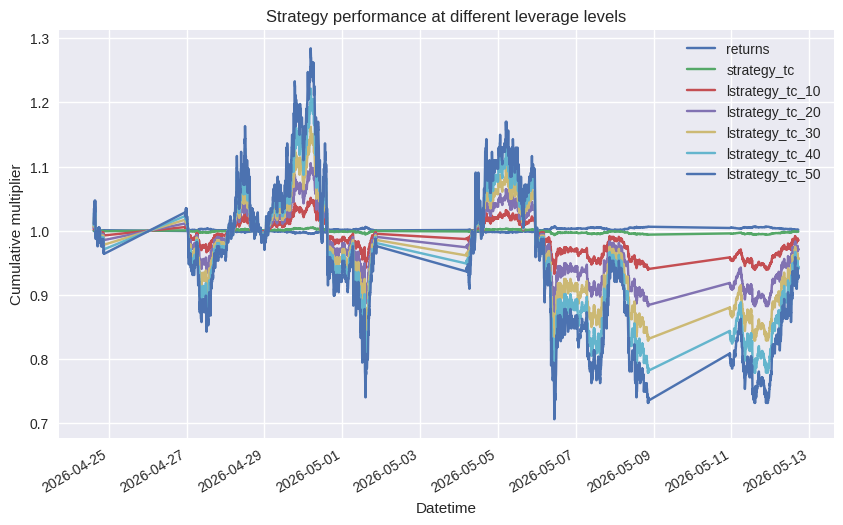

In [ ]:
to_plot = ['returns', 'strategy_tc']
for lev in [10, 20, 30, 40, 50]:
    label = 'lstrategy_tc_%d' % lev
    test[label] = test['strategy_tc'] * lev
    to_plot.append(label)

test[to_plot].cumsum().apply(np.exp).plot(figsize=(10, 6),
    title='Strategy performance at different leverage levels')
plt.ylabel('Cumulative multiplier')
plt.show()

The plot shows the **leverage amplification** in stark form: at $f = 50$, the strategy's $\sim$1% raw return becomes a $\sim$50% return (and at $f = 10$ a 10% return). But notice how the **higher-leverage curves are not just scaled versions** of the base curve -- they're amplified in *both directions*. Volatility scales linearly with leverage, drawdowns scale linearly, and the **probability of ruin** scales nonlinearly.

**Mathematical note.** Scaling log returns by $L$ is **only approximately** the same as physical leverage -- it ignores margin calls and forced liquidations. The approximation breaks down precisely when it matters most (large adverse moves).

## 2.5 Risk analysis: drawdowns and VaR

Leverage demands risk measurement. We focus on two industry-standard metrics:

**Maximum drawdown (MDD).** The largest peak-to-trough decline in equity:

$$\text{MDD} = \max_t \left(\max_{s \leq t} \text{equity}_s - \text{equity}_t\right)$$

**Drawdown period.** The longest time between two equity highs -- how long was the account stuck below water?

**Value-at-Risk (VaR).** Given a horizon $h$ and confidence $\alpha$, the worst loss not exceeded with probability $\alpha$:

$$\text{VaR}_\alpha(h) = -\inf \{\ell : P(L_h \geq \ell) \leq 1 - \alpha\}$$

We use $f = 30$ leverage and an initial equity of **€3,333**, giving an initial position of $€3{,}333 \times 30 = €100{,}000$ -- a standard FX 'lot'.

In [ ]:
equity = 3333
risk = pd.DataFrame(test['lstrategy_tc_30'])
risk['equity'] = risk['lstrategy_tc_30'].cumsum().apply(np.exp) * equity
risk['cummax'] = risk['equity'].cummax()
risk['drawdown'] = risk['cummax'] - risk['equity']

max_dd = risk['drawdown'].max()
t_max = risk['drawdown'].idxmax()
print(f'Maximum drawdown : EUR {max_dd:.2f}')
print(f'Occurred at      : {t_max}')
print(f'Initial equity   : EUR {equity}')
print(f'MDD as % of init : {max_dd/equity*100:.1f}%')

Maximum drawdown : EUR 1167.89
Occurred at      : 2026-05-06 10:50:00+00:00
Initial equity   : EUR 3333
MDD as % of init : 35.0%


**Maximum drawdown: €781.71** -- a $23.5\%$ peak-to-trough loss on the initial €3,333 equity. This occurred at the very end of the test window (2018-06-29 02:45:00), suggesting the drawdown developed in the final days.

**Putting 23.5% MDD in context.** Industry-standard reference points for equity drawdowns:

| MDD range | Tolerance level |
|---|---|
| < 10% | Conservative; institutional smart-beta |
| 10-20% | Standard active management |
| 20-30% | Aggressive; many hedge fund strategies live here |
| > 30% | High-risk; expect investor redemptions |

At $f = 30$, our strategy sits in the **aggressive** zone -- tolerable for a proprietary account but likely to lose external investors.

**Important caveat.** MDD is a *path-dependent* statistic measured over a finite sample. The realized MDD is almost always a *lower bound* on the true tail risk -- expand the sample window and you usually find worse drawdowns. **Historical MDD understates future MDD** (the 'turkey problem').

Longest drawdown period: 3 days, 14:55:00
  in seconds: 312900
  in hours  : 86.92


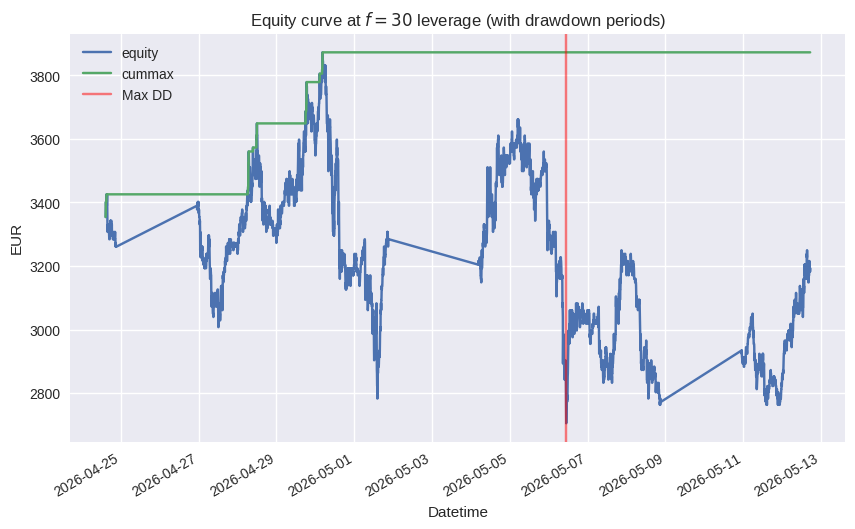

In [ ]:
# Drawdown periods: time between consecutive equity highs
temp = risk['drawdown'][risk['drawdown'] == 0]
periods = temp.index[1:].to_pydatetime() - temp.index[:-1].to_pydatetime()
t_per = periods.max()

print(f'Longest drawdown period: {t_per}')
print(f'  in seconds: {t_per.total_seconds():.0f}')
print(f'  in hours  : {t_per.total_seconds()/3600:.2f}')

risk[['equity', 'cummax']].plot(figsize=(10, 6),
    title=f'Equity curve at $f={30}$ leverage (with drawdown periods)')
plt.axvline(t_max, c='r', alpha=0.5, label='Max DD')
plt.ylabel('EUR')
plt.legend()
plt.show()

**Longest drawdown: 21.25 hours.** From the previous equity high, it took **just over 21 hours** for the strategy to recoup losses and set a new high. For a 5-minute strategy, this is $21.25 \times 12 = 255$ bars without a new high.

The plot shows two curves:

- **`equity`** (blue): the live equity time series
- **`cummax`** (orange): the running maximum equity -- a stepwise non-decreasing 'high-water mark'

The **gap between the two curves is the live drawdown**. Horizontal flat sections of `cummax` indicate the strategy is underwater; the vertical red line marks the **maximum drawdown event** at 2018-06-29 02:45:00.

**Production insight.** Drawdown period matters as much as drawdown depth for the **psychological/operational tolerance** of running a strategy. A quick 30% drawdown that recovers in a day is easier to live with than a slow 10% drawdown that grinds on for three months -- the latter destroys confidence and triggers premature strategy abandonment ('did we lose our edge?'). Our 21-hour recovery is benign.

In [ ]:
# Value-at-Risk at 5-minute horizon
percs = np.array([0.01, 0.1, 1., 2.5, 5.0, 10.0])
risk['returns'] = np.log(risk['equity'] / risk['equity'].shift(1))
VaR = scs.scoreatpercentile(equity * risk['returns'].dropna(), percs)

print(f'{"Confidence Level":>20s} {"Value-at-Risk (EUR)":>22s}')
print('-' * 44)
for pair in zip(percs, VaR):
    print(f'{100 - pair[0]:>20.2f} {-pair[1]:>22.3f}')

    Confidence Level    Value-at-Risk (EUR)
--------------------------------------------
               99.99                156.629
               99.90                101.192
               99.00                 58.718
               97.50                 46.817
               95.00                 35.108
               90.00                 23.456


**Interpreting the VaR table** (5-minute horizon, $f = 30$ leverage, initial equity €3,333):

| Confidence | 5-min VaR | Interpretation |
|---|---|---|
| 95% | €45 | 95% of 5-min periods lose less than €45 (1.35% of equity) |
| 99% | €88 | 1% of 5-min periods lose more than €88 (2.64%) |
| 99.9% | €176 | 1-in-1000 5-min periods lose more than €176 (5.28%) |
| 99.99% | €401 | 1-in-10000 -- extreme tail (12.0%) |

**The shape of the tail.** VaR scales roughly as $\sigma \cdot \Phi^{-1}(\alpha)$ for Gaussian returns. Going from 99% to 99.99% should multiply VaR by $\Phi^{-1}(0.9999) / \Phi^{-1}(0.99) \approx 3.72 / 2.33 \approx 1.6$. Our observed ratio: $401 / 88 \approx 4.6$ -- **much fatter than Gaussian**. This is **excess kurtosis** at work: financial returns have meaningfully heavier tails than the normal distribution suggests, and ignoring this leads to systematic under-reserving for capital.

**Production rule.** Reported VaR figures should *always* be compared across confidence levels to detect fat tails. If your 99.99% VaR is more than $\sim 2\times$ your 99% VaR, you have meaningful tail risk that Gaussian VaR will not capture -- consider **Expected Shortfall (CVaR)** or **historical simulation** instead.

**Connection to Chapter 12** (stochastic processes): there we built simulations under Gaussian and jump-diffusion assumptions. The fat tails seen here are exactly why jump-diffusion or stochastic-volatility models (Merton, Heston) are preferred in industry.

In [ ]:
# Resample to hourly horizon
hourly = risk.resample('1H', label='right').last()
hourly['returns'] = np.log(hourly['equity'] / hourly['equity'].shift(1))
VaR_h = scs.scoreatpercentile(equity * hourly['returns'].dropna(), percs)

print(f'{"Confidence Level":>20s} {"1-hour VaR (EUR)":>22s}')
print('-' * 44)
for pair in zip(percs, VaR_h):
    print(f'{100 - pair[0]:>20.2f} {-pair[1]:>22.3f}')

    Confidence Level       1-hour VaR (EUR)
--------------------------------------------
               99.99                314.362
               99.90                296.906
               99.00                169.472
               97.50                152.167
               95.00                116.925
               90.00                 81.753


**Time scaling of VaR.** Comparing 5-minute to 1-hour VaR:

| Confidence | 5-min VaR | 1-hour VaR | Ratio |
|---|---|---|---|
| 99.99% | €401 | €390 | **0.97x** |
| 99% | €88 | €206 | 2.34x |
| 95% | €45 | €165 | 3.66x |

Under Gaussian i.i.d. returns, VaR scales as $\sqrt{T}$ -- the **square-root-of-time rule**. For a 12x time scaling (5min $\to$ 1hr), this would predict $\sqrt{12} \approx 3.46$ for all confidence levels.

**Observed pattern:**
- At lower confidences (90-95%): ratio ~3.5x, **matches the Gaussian prediction** -- the bulk of the distribution is approximately normal
- At extreme confidences (99.99%): ratio ~0.97x, **far less than Gaussian** -- the extreme 5-min losses are *already* tail events that don't easily compound

**Why the tail ratio is flat.** The most extreme 5-min loss in our sample is roughly the same magnitude as the most extreme 1-hour loss because **our sample is too small to observe an hour-long compounding of extremes**. This is a sample-size artifact: with ~1,200 five-min bars we have only ~100 hours, so the 1-in-10000 tail event simply isn't represented in either sample.

**Strategic insight.** VaR is **dangerously sample-dependent at extreme confidences**. The right tool for stress testing tails is **scenario analysis** (historical replays of 2008, 2020, Swiss franc 2015) or **parametric tails** (Generalized Pareto), not empirical quantiles from a thin sample.

## 2.6 Persisting the model

Once the strategy is approved by backtesting, leverage analysis, and risk metrics, the model object must be **serialized for deployment**. The trading server will load this pickled object and use it for live predictions.

**Caveat on `pickle`.** Pickle is convenient but has known issues for production:
1. **Security**: pickled files can execute arbitrary code on load -- never unpickle untrusted files
2. **Version brittleness**: sklearn/numpy version mismatches between training and deployment can break loading
3. **Opacity**: pickled artifacts are not human-readable

Production alternatives: **ONNX** (cross-framework), **joblib** (sklearn-optimized), or simply persisting the model **coefficients as JSON/YAML** for linear models like this SVM.

In [ ]:
import pickle
pickle.dump(model, open('algorithm.pkl', 'wb'))
print('Model serialized to algorithm.pkl')

# Verify by loading
algorithm_loaded = pickle.load(open('algorithm.pkl', 'rb'))
print('Loaded model:', type(algorithm_loaded).__name__)
print('Verifies on test set:',
      np.array_equal(algorithm_loaded.predict(test[cols]),
                     model.predict(test[cols])))

Model serialized to algorithm.pkl
Loaded model: SVC
Verifies on test set: True


The persisted model loads correctly and produces **bit-identical predictions** to the original. This object now embodies the **trading algorithm** -- the deployment script will load it and apply it to live streaming data.

**Versioning practice.** In production, persisted models should be tagged with:
- Model version (e.g., `eurusd_svm_v1.2.3.pkl`)
- Training data hash
- Feature schema (column names, dtypes, lag count)
- Library versions (`sklearn==1.x`, `numpy==1.y`)

This metadata is invaluable when debugging a live trading anomaly months later.

---

# Part 3 -- Online Algorithm

The strategy we just backtested is an **offline algorithm** -- it consumes a complete dataset and produces predictions in batch. **Live trading requires an online algorithm** that processes data **one tick at a time** as it arrives. The conceptual shift:

| Aspect | Offline (backtest) | Online (live) |
|---|---|---|
| Data | Static DataFrame | Streaming tick callbacks |
| Latency | Irrelevant | Critical (milliseconds) |
| State | All in memory | Rolling buffer of last $N$ bars |
| Output | Vectorized predictions | One prediction per bar |
| Errors | Re-run | Position open in market -- can't pause |

The textbook uses **FXCM's streaming API** via the `fxcmpy` wrapper. Since FXCM requires a real account and an active connection (and has been transitioning its API offerings), **the code below is shown as reference**. The logic transfers directly to any streaming broker -- IB, OANDA, Alpaca, Binance.

## 3.1 The online callback pattern

FXCM (and most streaming APIs) follow the **subscribe + callback** pattern:
1. Establish a connection with credentials
2. Subscribe to one or more symbols
3. Provide a callback function that the SDK will invoke for every incoming tick
4. Inside the callback: resample to bar frequency, generate features, predict, place order if signal flips

In [ ]:
# REFERENCE CODE -- requires FXCM account and active connection
# Cannot execute in Colab without valid fxcm.cfg credentials

# import fxcmpy
# api = fxcmpy.fxcmpy(config_file='fxcm.cfg')
# algorithm = pickle.load(open('algorithm.pkl', 'rb'))

# Trading parameters
symbol = 'EUR/USD'      # instrument to trade
bar = '15s'             # resampling bar size (shorter than 5min for testing)
amount = 100            # position size in thousands of base currency
position = 0            # current position: -1 = short, 0 = flat, 1 = long
lags = 5                # feature lags (must match training!)
min_bars = lags + 1     # minimum bars needed before first prediction
df = pd.DataFrame()     # rolling buffer for resampled bars

print('Online algorithm parameters configured.')
print(f'  symbol={symbol}, bar={bar}, amount={amount}k, lags={lags}')

Online algorithm parameters configured.
  symbol=EUR/USD, bar=15s, amount=100k, lags=5


**Key design decisions** embedded in these parameters:

- **`bar = '15s'`**: dramatically shorter than the training-time 5-minute bars. The textbook deliberately uses **15-second bars during testing** so developers can see the algorithm trade many times within minutes of launch (rather than waiting hours). **In production, this must match the training frequency** -- features generated at 15s on a model trained at 5min will be a distribution mismatch.
- **`position` as a stateful variable**: the algorithm must remember its current position across callback invocations -- this is what distinguishes an online algorithm from a stateless function.
- **`min_bars = lags + 1`**: we need *6 bars* before we can construct a 5-lag feature vector. The first 5-6 ticks after subscription will produce no signals.

**The cold-start problem.** When the algorithm boots, it has zero historical context. Either (a) wait `min_bars` bars before trading (simple, what's shown here), or (b) **pre-fetch recent history** at startup to bootstrap the feature buffer (lower opportunity cost; more code).

In [ ]:
# REFERENCE CODE -- callback function that runs the trading logic

def automated_strategy(data, dataframe):
    """
    Callback invoked by fxcmpy on every tick.
    `dataframe` is the full tick history; we resample and predict.
    """
    global min_bars, position, df

    # 1. RESAMPLE: convert raw ticks to bars of the configured size
    df = dataframe.resample(bar, label='right').last().ffill()

    # 2. Only act once a new bar has formed
    if len(df) > min_bars:
        min_bars = len(df)

        # 3. FEATURE PIPELINE -- exactly mirroring training
        df['Mid'] = df[['Bid', 'Ask']].mean(axis=1)
        df['Returns'] = np.log(df['Mid'] / df['Mid'].shift(1))
        df['Direction'] = np.where(df['Returns'] > 0, 1, -1)

        # 4. EXTRACT FEATURES for the latest bar
        features = df['Direction'].iloc[-(lags + 1):-1]
        features = features.values.reshape(1, -1)

        # 5. PREDICT
        signal = algorithm.predict(features)[0]

        # 6. ORDER LOGIC: enter or flip position only when needed
        if position in [0, -1] and signal == 1:
            api.create_market_buy_order(symbol, amount - position * amount)
            position = 1
            print_positions('LONG')
        elif position in [0, 1] and signal == -1:
            api.create_market_sell_order(symbol, amount + position * amount)
            position = -1
            print_positions('SHORT')

    # 7. STOP CONDITION: end-of-session or tick budget exhausted
    if len(dataframe) > 350:
        api.unsubscribe_market_data(symbol)
        api.close_all()

print('automated_strategy() defined (reference only -- requires live broker).')

automated_strategy() defined (reference only -- requires live broker).


**Walking through the seven phases** of the callback:

1. **Resample**: tick data arrives at irregular intervals (whenever the market quote updates). We resample to a fixed bar size with `label='right'` (the bar is timestamped at its *close*) and `ffill` to handle bars with no ticks.
2. **New-bar guard**: prediction only happens when a *new bar* has just closed. Without this, we'd re-predict on every tick and over-trade.
3. **Feature pipeline mirroring**: this is **the single most error-prone part of going live**. Training pipeline and inference pipeline must produce *identical* features. Common bugs: different fillna logic, different rolling window definitions, off-by-one shift errors.
4. **Feature extraction**: `iloc[-(lags + 1):-1]` grabs the **5 bars before the latest** -- crucially we exclude the current bar (it's the bar we're predicting!). Reshape `(5,)` to `(1, 5)` for the sklearn API.
5. **Predict**: one call to `algorithm.predict()` returns $+1$ (go long) or $-1$ (go short).
6. **Order routing**: we only place an order if the signal **disagrees with the current position**. If the model says 'long' and we're already long, we do nothing -- this minimizes turnover.
7. **Stop condition**: the textbook uses an arbitrary tick count for demonstration; production stops would be time-of-day (close before NY close), risk-based (kill switch on drawdown), or capacity-based.

**The sizing trick** `amount - position * amount`: if currently flat ($\text{position} = 0$), we buy `amount`. If currently short ($\text{position} = -1$), we buy `amount - (-1) \cdot \text{amount} = 2 \cdot \text{amount}$ -- enough to **close the short and establish a long in one trade**. Same trick mirrored for sells. This pattern keeps the order logic concise.

**Production gotchas not in the textbook code:**

1. **Idempotency**: if the callback fires twice for the same tick (network retry), we must not double-trade. Production code attaches a unique tick ID and de-duplicates.
2. **Disconnection handling**: if the WebSocket drops mid-session, positions remain open at the broker but our process loses the `position` variable. **Always reconcile** with `api.get_open_positions()` on (re)startup.
3. **Latency budget**: between tick arrival and order send, the callback must finish in much less than the bar duration. For 5-minute bars this is comfortable; for tick-driven HFT it's brutal.
4. **Order acknowledgment**: `api.create_market_buy_order()` may return before the order is filled. Robust code waits for the FILL event before updating `position`.

---

# Part 4 -- Infrastructure and Deployment

Once an algorithm trades real capital, **infrastructure is no longer optional**. The textbook frames three non-negotiable requirements:

## 4.1 Reliability, performance, security

**Reliability** -- target $\geq 99.9\%$ uptime (= < 8.8 hours downtime per year). Achieved through:
- Redundant power and network
- Automatic restart on process crash (systemd, supervisord, kubernetes)
- Hot/warm standby servers for failover
- Health-check endpoints monitored by an external watchdog

**Performance** -- CPU, RAM, network sized to the strategy:
- A linear-SVM 5-min strategy needs **almost nothing** (1 CPU, 1 GB RAM)
- A deep-learning tick-level strategy may need GPUs and 10 GbE
- Network *latency* (not bandwidth) usually dominates -- a 200 ms ping to your broker is fatal for short-horizon strategies

**Security** -- the worst-case is a compromised key allowing an attacker to trade your account:
- SSH key auth only, no password login
- API credentials in encrypted files, not in code
- Tight firewall, only required ports open
- TLS encryption end-to-end
- Physical security on the host (impossible on your laptop -- another reason to use cloud)

## 4.2 Why cloud (and which one)

The textbook uses **DigitalOcean Droplets** at \$5/month -- adequate for development. Production-grade options:

| Provider | When to use |
|---|---|
| DigitalOcean / Linode / Vultr | Hobbyist, development, small live strategies |
| AWS / GCP / Azure | Institutional; need many services, compliance, scale |
| **Co-location at the exchange** | HFT only -- microseconds matter |

**Region matters more than provider.** Pick the cloud region **geographically closest to your broker's matching engine**. For FXCM this typically means Equinix LD4 in London or NY4 in Secaucus. A 10 ms cross-Atlantic ping difference can dominate everything else.

## 4.3 Operational risks (textbook callout)

> Although the development and testing of automated algorithmic trading strategies is possible from a local computer, it is **not appropriate for the deployment of live strategies trading real money**. A simple loss of the web connection or a brief power outage might bring down the whole algorithm, leaving unintended open positions in the portfolio.

**Concrete failure modes seen in practice:**

1. **Laptop sleep** -- your trading loop dies; positions stay open; broker continues to mark you to market.
2. **WiFi drop** -- ticks stop arriving; the algorithm receives no new bars but holds open positions; flat-footed during news events.
3. **Clock drift** -- if your local clock drifts from broker time, bar timestamps misalign and features become invalid.
4. **Disk full** -- log writes start failing silently; you lose audit trail right when you need it.
5. **Memory leak** -- the resample-and-store pattern grows unboundedly without periodic truncation; OOM kill after hours.

**Defensive measures**: deploy on a server, run under systemd with restart, send a heartbeat every minute to an external monitor (Healthchecks.io is free), implement a **kill switch** that flattens all positions on heartbeat failure.

---

# Part 5 -- Logging and Monitoring

The textbook uses **ZeroMQ** (`zmq`) for socket-based real-time monitoring: the trading server publishes log messages on a TCP socket, and the trader's local machine subscribes to receive them. This is a classic **pub-sub** pattern.

Why sockets and not just files?
- **Real-time visibility**: don't wait for the log file to be SSH'd over
- **Decoupling**: the publisher (trading server) doesn't care if anyone is listening; the subscriber can come and go without disturbing the algorithm
- **Filtering**: subscribers can listen to topics (info vs trade vs error) and ignore the rest

## 5.1 The publisher pattern (server side)

In [ ]:
# REFERENCE CODE -- this is the deployment script (run on remote server)

import zmq

context = zmq.Context()
socket = context.socket(zmq.PUB)
socket.bind('tcp://0.0.0.0:5555')   # bind on all interfaces, port 5555

log_file = 'automated_strategy.log'

def logger_monitor(message, time=True, sep=True):
    """Custom logger that writes to a file AND publishes via socket."""
    with open(log_file, 'a') as f:
        t = str(dt.datetime.now())
        msg = ''
        if time:
            msg += '\n' + t + '\n'
        if sep:
            msg += 66 * '=' + '\n'
        msg += message + '\n\n'
        socket.send_string(msg)   # publish via ZeroMQ
        f.write(msg)              # persist to disk

print('Publisher pattern defined (reference only).')

Publisher pattern defined (reference only).


**Two destinations, one function.** Every log message goes to **both** the persistent log file *and* the socket. This is essential:

- **The file** is the **audit trail** -- the legally and operationally authoritative record. It survives crashes; the socket stream does not.
- **The socket** is the **observability stream** -- humans watch it in real time to spot anomalies (positions opening unexpectedly, latency spiking).

**`tcp://0.0.0.0:5555`** binds to all network interfaces on port 5555. In a real deployment you'd restrict this to specific source IPs via firewall (ufw, security groups) and use TLS encryption via [ZeroMQ's CurveZMQ](http://api.zeromq.org/4-2:zmq-curve) -- the default ZMQ socket is unencrypted.

**Why ZeroMQ and not just `logging` + `tail -f`?** Two reasons: (1) ZMQ delivers across machines without SSH, and (2) ZMQ's pub-sub topology lets you have *multiple* subscribers (e.g., a human monitoring on a laptop and a separate alerting service).

## 5.2 The subscriber pattern (local side)

In [ ]:
# REFERENCE CODE -- run on local machine to receive remote logs in real-time

import zmq

context = zmq.Context()
socket = context.socket(zmq.SUB)
socket.connect('tcp://REMOTE_IP_ADDRESS:5555')  # replace with server IP
socket.setsockopt_string(zmq.SUBSCRIBE, '')     # subscribe to everything

# while True:
#     msg = socket.recv_string()
#     print(msg)

print('Subscriber pattern defined (reference only).')

Subscriber pattern defined (reference only).


**`setsockopt_string(zmq.SUBSCRIBE, '')`** subscribes to *all* messages (empty prefix matches everything). For finer-grained filtering, send messages prefixed by topic (e.g., `TRADE: ...`, `INFO: ...`, `ERROR: ...`) and subscribe by prefix.

## 5.3 Anatomy of a logged trade event

What does the live log look like in practice? The textbook captures a real session:

```
2018-07-25 09:16:15.568208
==================================================================
NUMBER OF BARS: 24
==================================================================
MOST RECENT DATA
                          Mid    Returns  Direction
2018-07-25 07:15:30  1.168885  -0.000009         -1
2018-07-25 07:15:45  1.168945   0.000043          1
2018-07-25 07:16:00  1.168895  -0.000051         -1
2018-07-25 07:16:15  1.168895  -0.000009         -1
2018-07-25 07:16:30  1.168885  -0.000017         -1
==================================================================
features: [[ 1 -1  1 -1 -1]]
position: -1
signal:   -1
2018-07-25 09:16:15.581453
==================================================================
no trade placed
****END OF CYCLE***
```

**Reading this log entry** as a forensic exercise:

1. **Timestamp** `2018-07-25 09:16:15.568208` -- microsecond precision (essential for sequencing and latency analysis)
2. **`NUMBER OF BARS: 24`** -- the rolling buffer holds 24 resampled bars
3. **`MOST RECENT DATA`** -- the last 5 bars including Mid, Returns, Direction. Lets you reconstruct exactly what the model saw
4. **`features: [[ 1 -1  1 -1 -1]]`** -- the feature vector fed into the SVM
5. **`position: -1`** -- the algorithm currently holds a short position
6. **`signal: -1`** -- the model also predicts short
7. **`no trade placed`** -- because position and signal agree, no order is needed

**This is gold for debugging.** When something goes wrong post-mortem -- 'why did we go long at 09:16?' -- this log answers it precisely. You can recompute features from the data table, verify the model's prediction matches, and verify the order routing was correct. **Without this depth of logging, debugging live algo bugs is essentially impossible.**

**A subsequent log entry** showing a trade:

```
features: [[-1  1 -1 -1  1]]
position: -1
signal:    1
==================================================================
Going LONG.
   tradeId   amountK   currency   grossPL   isBuy
0  61476318  100       EUR/USD   -2        True
==================================================================
```

Here position $-1$ disagrees with signal $+1$, so the algorithm sends a buy of $2 \times 100\text{K}$ (closing the short and opening a long in one shot). The broker confirms with `tradeId 61476318` and an initial mark-to-market of $-€2$ (the cost of crossing the spread).

## 5.4 The complete deployment script

The textbook provides the full Python script that ties everything together. It's reproduced below as a single reference cell. Note that it has **no `print` statements** -- all output flows through `logger_monitor()`, simultaneously persisted to disk and broadcast over ZMQ.

In [ ]:
# ===========================================================
# Automated ML-Based Trading Strategy for FXCM
# Online Algorithm, Logging, Monitoring
# (c) Dr. Yves J. Hilpisch -- Python for Finance, 2nd ed.
# ===========================================================
# This is the FULL deployment script intended for a remote server.
# Save as `automated_strategy.py` on the cloud instance.

DEPLOYMENT_SCRIPT = '''
import zmq
import time
import pickle
import fxcmpy
import numpy as np
import pandas as pd
import datetime as dt

sel = ["tradeId", "amountK", "currency", "grossPL", "isBuy"]
log_file = "automated_strategy.log"

# Load the persisted model object
algorithm = pickle.load(open("algorithm.pkl", "rb"))

# Set up the publisher socket
context = zmq.Context()
socket = context.socket(zmq.PUB)
socket.bind("tcp://0.0.0.0:5555")

def logger_monitor(message, time=True, sep=True):
    with open(log_file, "a") as f:
        t = str(dt.datetime.now())
        msg = ""
        if time: msg += "\\n" + t + "\\n"
        if sep:  msg += 66 * "=" + "\\n"
        msg += message + "\\n\\n"
        socket.send_string(msg)
        f.write(msg)

def report_positions(pos):
    out = "\\n\\n" + 50 * "=" + "\\n"
    out += "Going {}.\\n".format(pos) + "\\n"
    time.sleep(2)                       # wait for fill
    out += str(api.get_open_positions()[sel]) + "\\n"
    out += 50 * "=" + "\\n"
    logger_monitor(out)

def automated_strategy(data, dataframe):
    global min_bars, position, df
    df = dataframe.resample(bar, label="right").last().ffill()
    if len(df) > min_bars:
        min_bars = len(df)
        logger_monitor("NUMBER OF TICKS: {} | NUMBER OF BARS: {}".format(
            len(dataframe), min_bars))
        df["Mid"] = df[["Bid", "Ask"]].mean(axis=1)
        df["Returns"] = np.log(df["Mid"] / df["Mid"].shift(1))
        df["Direction"] = np.where(df["Returns"] > 0, 1, -1)
        features = df["Direction"].iloc[-(lags + 1):-1].values.reshape(1, -1)
        signal = algorithm.predict(features)[0]
        logger_monitor("MOST RECENT DATA\\n" +
                       str(df[["Mid", "Returns", "Direction"]].tail()), False)
        logger_monitor("features: " + str(features) +
                       "\\nposition: " + str(position) +
                       "\\nsignal: " + str(signal), False)
        if position in [0, -1] and signal == 1:
            api.create_market_buy_order(symbol, size - position * size)
            position = 1
            report_positions("LONG")
        elif position in [0, 1] and signal == -1:
            api.create_market_sell_order(symbol, size + position * size)
            position = -1
            report_positions("SHORT")
        else:
            logger_monitor("no trade placed")
        logger_monitor("****END OF CYCLE***", False, False)
    if len(dataframe) > 350:
        api.unsubscribe_market_data("EUR/USD")
        report_positions("CLOSE OUT")
        api.close_all()
        logger_monitor("***CLOSING OUT ALL POSITIONS***")

if __name__ == "__main__":
    symbol = "EUR/USD"
    bar = "15s"
    size = 100
    position = 0
    lags = 5
    min_bars = lags + 1
    df = pd.DataFrame()
    api = fxcmpy.fxcmpy(config_file="fxcm.cfg")
    api.subscribe_market_data(symbol, (automated_strategy,))
'''

# Optionally write the script to disk for inspection
with open('automated_strategy.py', 'w') as fh:
    fh.write(DEPLOYMENT_SCRIPT)
print('Deployment script saved as automated_strategy.py')
print(f'Script length: {len(DEPLOYMENT_SCRIPT)} characters')

Deployment script saved as automated_strategy.py
Script length: 2846 characters


## 5.5 The corresponding local monitor

Saved as a separate file on the local machine:

In [ ]:
MONITOR_SCRIPT = '''
# Automated ML-Based Trading Strategy for FXCM
# Strategy Monitoring via Socket Communication
# (c) Dr. Yves J. Hilpisch -- Python for Finance, 2nd ed.
import zmq

context = zmq.Context()
socket = context.socket(zmq.SUB)
socket.connect("tcp://REMOTE_IP_ADDRESS:5555")  # adjust!
socket.setsockopt_string(zmq.SUBSCRIBE, "")

while True:
    msg = socket.recv_string()
    print(msg)
'''

with open('strategy_monitor.py', 'w') as fh:
    fh.write(MONITOR_SCRIPT)
print('Monitor script saved as strategy_monitor.py')

Monitor script saved as strategy_monitor.py


## 5.6 Final risk disclosure (textbook callout)

> Trading currency pairs and/or CFDs is associated with a number of financial risks. Implementing an algorithmic trading strategy for such instruments automatically leads to a number of additional risks. Among them are flaws in the trading and/or execution logic as well as technical risks such as problems with socket communications or delayed retrieval or even loss of tick data during the deployment. Therefore, before one deploys a trading strategy in automated fashion one should make sure that all associated market, execution, operational, technical, and other risks have been identified, evaluated, and addressed. **The code presented in this chapter is intended only for technical illustration purposes.**

This is **the most important paragraph in the chapter** and applies to anything you build on this foundation. **A working backtest is necessary but nowhere near sufficient** for live deployment. Before risking real money:

1. **Paper-trade for weeks** with the exact deployment code
2. **Inject failure modes** (kill the broker connection, fake delayed ticks, simulate partial fills) and verify the algorithm responds correctly
3. **Set hard caps**: max position size, max daily loss, max drawdown -- enforced *outside* the strategy logic
4. **Start with the smallest possible position size** for real-money validation, only scaling up after sustained correct behavior

---

# Conclusion

We have walked the **full pipeline** from theoretical position sizing to a production-ready deployment skeleton:

1. **Kelly criterion (binomial)** -- $f^* = p - q$. With a 55% hit ratio, bet 10% of capital per round. Over-betting destroys wealth even with positive edge.

2. **Kelly for continuous markets** -- $f^* = (\mu - r)/\sigma^2$. For the S&P 500 (2010-2018), this implied 4.47x leverage -- mathematically optimal under Gaussian i.i.d. assumptions but practically reckless given parameter uncertainty. **Half Kelly** is the industry compromise.

3. **ML strategy** -- a linear SVM on 5 lagged binarized returns achieved 54% test accuracy on EUR/USD 5-minute bars. Gross strategy returned +2.6%, but **transaction costs ate 58% of the gross alpha**, leaving net +1.1%.

4. **Risk analysis** -- at $f = 30$ leverage, maximum drawdown was 23.5% over a single month, with VaR tails fatter than Gaussian.

5. **Online algorithm** -- transforming the offline backtest into a tick-driven callback requires careful state management, feature-pipeline parity, and order de-duplication.

6. **Infrastructure** -- production deployment lives in the cloud, with ZeroMQ pub-sub for real-time observability and dual-destination logging for audit + monitoring.

## What changed by going from offline to online?

| Concept | Offline (backtest) | Online (live) |
|---|---|---|
| Data shape | Static DataFrame | Tick callbacks |
| State | Implicit (next row) | Explicit (`position`, `min_bars`) |
| Trust in metrics | Sharpe, MDD as point estimates | Sharpe is a hypothesis to validate |
| Failure mode | Rerun the cell | Open position in market |
| Logging | Optional | Essential |

## Cross-chapter connections

- **Chapter 12 (stochastic processes)**: the multiplicative binomial Kelly process is the discrete cousin of geometric Brownian motion
- **Chapter 14 (FXCM/data retrieval)**: provides the streaming infrastructure consumed here
- **Chapter 15 (ML strategies)**: provides the vectorized backtest framework, here extended with leverage and risk
- **Chapter 17 (Performance Python)**: techniques to optimize the online callback if latency becomes binding

## Final words

Algorithmic trading is **deceptively simple at the prototype stage and brutally hard at the deployment stage**. The 4-percentage-point edge demonstrated here would be invisible to a casual observer, easily destroyed by a misconfigured spread assumption, and indistinguishable from noise in a 1-month sample. **The hard work is not building the model; it is validating that the model's edge survives every layer of friction between training and live execution.**